# ML-only U/L Sweep Notebook

This notebook is a **separate ML pipeline** that assumes your baseline algorithms were already run.

## What it does
1. Builds ML features and labels for each `U/L`
2. Trains an MLP to predict `(beta, eta)`
3. Evaluates **D-OPS** and **D-OPS*`
4. Loads the saved baseline summary
5. Filters baseline points to match the ML `U/L` values
6. Produces the final combined plot

In [17]:
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as TorchDataLoader
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

from Dataloader import DataLoader
from MyAlg import MyAlg

## 2. Global configuration

In [18]:
TIMEZONE = "America/Los_Angeles"

ACN_2019_JSON = "dataset/jan19_dec19.json"
WEATHER_2019 = "dataset/weatherdata19.csv"

ACN_2020_JSON = "dataset/jan_feb_2020.json"
WEATHER_2020 = "dataset/weatherdata20.csv"

# VALUE_MODE = "fixed"
VALUE_MODE = "stationwise"

K = 3
NUMBER_OF_STATIONS = K

target_total_capacity = 1.0
TOTAL_CAPACITY_LIST = [target_total_capacity]

L_value = 1
U_list = [6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
ratio_list = [u / L_value for u in U_list]

NUM_RANDOM_PARAM_PAIRS = 50
BETA_LOW = 1.5
BETA_HIGH = 10.0
ETA_LOW = 1.0
ETA_HIGH = 10.0

NUM_VALUE_REPLICATIONS = 4
BASE_SEED_2019 = 1000
BASE_SEED_2020 = 2000

ML_SEED = 42
VAL_FRAC = 0.15
EPOCHS = 300
PATIENCE = 20
BATCH_SIZE = 32

ML_ROOT = f"ul_sweep_ml_only_{VALUE_MODE}"
os.makedirs(ML_ROOT, exist_ok=True)

BASELINE_SUMMARY_PATH = f"results_ul_sweep/avg_cr_vs_u_over_l_{VALUE_MODE}.csv"
OFFLINE_CSV_TEMPLATE = f"results_ul_sweep/offline_U{{U}}_L{{L}}_{VALUE_MODE}.csv"

print("U/L ratios =", ratio_list)
print("ML root =", ML_ROOT)
print("Baseline summary path =", BASELINE_SUMMARY_PATH)
print("Offline CSV template =", OFFLINE_CSV_TEMPLATE)

U/L ratios = [6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0, 28.0, 30.0]
ML root = ul_sweep_ml_only_stationwise
Baseline summary path = results_ul_sweep/avg_cr_vs_u_over_l_stationwise.csv
Offline CSV template = results_ul_sweep/offline_U{U}_L{L}_stationwise.csv


## 3. Utility helpers

In [19]:
def load_csv(path):
    if os.path.exists(path):
        return pd.read_csv(path)
    return None


def safe_ratio(num, den, eps=1e-12):
    if pd.isna(num) or pd.isna(den):
        return np.nan
    if float(den) <= eps:
        return np.nan
    return float(num) / float(den)

## 4. Data/date helpers

In [20]:
def get_start_date_from_json(acn_json_path: str, timezone: str) -> pd.Timestamp:
    with open(acn_json_path, "r") as f:
        raw = json.load(f)
    start_utc = pd.to_datetime(raw["_meta"]["start"], utc=True)
    start_local = start_utc.tz_convert(timezone)
    return start_local.floor("D").tz_localize(None)


def load_acn_sessions(acn_json_path: str) -> pd.DataFrame:
    with open(acn_json_path, "r") as f:
        raw = json.load(f)
    if "_items" not in raw:
        raise ValueError("ACN JSON must contain key '_items'.")
    df = pd.DataFrame(raw["_items"])
    if df.empty:
        raise ValueError("ACN JSON '_items' is empty.")
    return df


def add_dow_features(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    out = df.copy()
    dow = pd.to_datetime(out[date_col]).dt.weekday
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7.0)
    out["is_weekend"] = (dow >= 5).astype(float)
    return out

## 5. Demand and weather features

In [21]:
def build_daily_demand(sessions_df: pd.DataFrame, timezone: str, time_col: str = "connectionTime", kwh_col: str = "kWhDelivered") -> pd.DataFrame:
    df = sessions_df.copy()
    df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")
    df = df.dropna(subset=[time_col])
    df[time_col] = df[time_col].dt.tz_convert(timezone)
    df["date"] = df[time_col].dt.floor("D").dt.tz_localize(None)
    df[kwh_col] = pd.to_numeric(df[kwh_col], errors="coerce").fillna(0.0)
    daily = (
        df.groupby("date", as_index=False)[kwh_col]
        .sum()
        .rename(columns={kwh_col: "demand"})
        .sort_values("date")
        .reset_index(drop=True)
    )
    daily = add_dow_features(daily, "date")
    daily["demand_lag1"] = daily["demand"].shift(1)
    daily["demand_lag2"] = daily["demand"].shift(2)
    daily = daily.dropna(subset=["demand_lag1", "demand_lag2"]).reset_index(drop=True)
    return daily


def parse_tmp_to_celsius(tmp_str):
    if pd.isna(tmp_str):
        return np.nan
    s = str(tmp_str).strip()
    if not s:
        return np.nan
    val = s.split(",")[0].strip()
    if val in {"+9999", "9999", "-9999"}:
        return np.nan
    try:
        return float(val) / 10.0
    except ValueError:
        return np.nan


def build_daily_temperature(weather_csv_path: str, timezone: str, date_col: str = "DATE", tmp_col: str = "TMP") -> pd.DataFrame:
    w = pd.read_csv(weather_csv_path, low_memory=False)
    w["timestamp"] = pd.to_datetime(w[date_col], utc=True, errors="coerce")
    w = w.dropna(subset=["timestamp"])
    w["timestamp"] = w["timestamp"].dt.tz_convert(timezone)
    w["date"] = w["timestamp"].dt.floor("D").dt.tz_localize(None)
    w["temperature"] = w[tmp_col].apply(parse_tmp_to_celsius)
    daily_temp = (
        w.groupby("date")["temperature"]
        .agg(temp_mean="mean", temp_min="min", temp_max="max", temp_std="std")
        .reset_index()
        .sort_values("date")
        .reset_index(drop=True)
    )
    return daily_temp

## 6. Dataloader replication helpers

In [22]:
def build_one_dataloader_and_instances(acn_json_path, num_stations, seed, value_mode=VALUE_MODE, fav_alpha=0.3, ev_multiplier=20, delta_minutes=15, instance_length_hours=24, L=1, U=20):
    dl = DataLoader(
        filepath=acn_json_path,
        delta_minutes=delta_minutes,
        instance_length_hours=instance_length_hours,
        L=L,
        U=U,
        ev_multiplier=ev_multiplier,
        num_stations=num_stations,
        value_mode=value_mode,
        fav_alpha=fav_alpha,
        seed=seed,
    )
    return dl, list(dl)


def build_replicated_instances(acn_json_path, num_stations, num_replications, base_seed, L, U):
    replications = []
    for rep_id in range(num_replications):
        seed = int(base_seed + rep_id)
        dl, instances = build_one_dataloader_and_instances(
            acn_json_path=acn_json_path,
            num_stations=num_stations,
            seed=seed,
            L=L,
            U=U,
        )
        replications.append({
            "replicate_id": int(rep_id),
            "seed": int(seed),
            "dataloader": dl,
            "instances": instances,
        })
    return replications

## 7. Value lag features and merged features

In [23]:
def build_avg_value_features_from_replications(replicated_instances, start_date, K) -> pd.DataFrame:
    rows = []
    for rep in replicated_instances:
        replicate_id = int(rep["replicate_id"])
        instances = rep["instances"]
        for inst_idx, instance in enumerate(instances):
            date = (start_date + pd.Timedelta(days=int(inst_idx))).floor("D")
            station_vals = [[] for _ in range(K)]
            for ev in instance:
                vks = ev.get("value", None)
                if vks is None:
                    continue
                for k in range(K):
                    station_vals[k].append(float(vks[k]))
            row = {"replicate_id": replicate_id, "instance_id": int(inst_idx), "date": date, "num_evs": len(instance)}
            for k in range(K):
                vals_k = station_vals[k]
                row[f"avg_value_s{k}"] = float(np.mean(vals_k)) if len(vals_k) else 0.0
            rows.append(row)
    df = pd.DataFrame(rows).sort_values(["replicate_id", "date"]).reset_index(drop=True)
    for k in range(K):
        df[f"avg_value_s{k}_lag1"] = df.groupby("replicate_id")[f"avg_value_s{k}"].shift(1)
    lag_cols = [f"avg_value_s{k}_lag1" for k in range(K)]
    df = df.dropna(subset=lag_cols).reset_index(drop=True)
    return df


def build_features_from_replications(acn_json_path: str, weather_csv_path: str, timezone: str, replicated_instances, start_date, K) -> pd.DataFrame:
    sessions_df = load_acn_sessions(acn_json_path)
    daily_demand = build_daily_demand(sessions_df=sessions_df, timezone=timezone, time_col="connectionTime", kwh_col="kWhDelivered")
    daily_temp = build_daily_temperature(weather_csv_path=weather_csv_path, timezone=timezone, date_col="DATE", tmp_col="TMP")
    common_df = daily_demand.merge(daily_temp, on="date", how="left")
    temp_cols = ["temp_mean", "temp_min", "temp_max", "temp_std"]
    common_df[temp_cols] = common_df[temp_cols].ffill().bfill()
    avg_value_df = build_avg_value_features_from_replications(replicated_instances=replicated_instances, start_date=start_date, K=K)
    keep_cols = ["replicate_id", "instance_id", "date", "num_evs"] + [f"avg_value_s{k}_lag1" for k in range(K)]
    features_df = avg_value_df[keep_cols].merge(common_df, on="date", how="inner")
    return features_df.sort_values(["replicate_id", "instance_id", "date"]).reset_index(drop=True)

## 8. MyAlg evaluation and label search

In [24]:
def eval_instance_scalar(instance, capacities, time_window, beta, eta):
    alg = MyAlg(capacities, time_window)
    alg.set_beta(float(beta))
    alg.set_eta(float(eta))
    alg.reset()
    total_utility = 0.0
    admitted_evs = 0
    for ev in instance:
        admit, schedule = alg.decide(ev)
        if not admit:
            continue
        alg.admit(schedule)
        admitted_evs += 1
        chosen_station = next(iter(schedule))
        total_utility += float(ev["value"][chosen_station])
    return total_utility, admitted_evs


def sample_random_beta_eta_pairs(num_pairs, beta_low, beta_high, eta_low, eta_high, seed):
    rng = np.random.default_rng(seed)
    beta_arr = rng.uniform(beta_low, beta_high, size=num_pairs)
    eta_arr = rng.uniform(eta_low, eta_high, size=num_pairs)
    return [(float(beta_arr[i]), float(eta_arr[i])) for i in range(num_pairs)]


def search_best_random_beta_eta_pair(instance, capacities, time_window, beta_eta_pairs):
    best_beta = None
    best_eta = None
    best_score = float("-inf")
    best_admitted = 0
    for beta, eta in beta_eta_pairs:
        utility, admitted_evs = eval_instance_scalar(instance=instance, capacities=capacities, time_window=time_window, beta=float(beta), eta=float(eta))
        if utility > best_score:
            best_score = float(utility)
            best_beta = float(beta)
            best_eta = float(eta)
            best_admitted = int(admitted_evs)
    return best_beta, best_eta, best_score, best_admitted


def compute_avg_instance_demand(instances):
    if len(instances) == 0:
        return 0.0
    return float(np.mean([sum(float(ev["demand"]) for ev in instance) for instance in instances]))


def make_scalar_labels_by_load_factor_from_replications(replicated_instances, start_date, number_of_stations, total_capacity_list, time_window, avg_demand, out_csv, num_random_param_pairs, beta_low, beta_high, eta_low, eta_high):
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    rows = []
    for C_total in tqdm(total_capacity_list, desc=f"Capacities -> {os.path.basename(out_csv)}"):
        base_cap = float(C_total) / float(number_of_stations)
        capacities = [base_cap] * int(number_of_stations)
        load_factor = float(avg_demand) / (float(C_total) * float(time_window))
        for rep in replicated_instances:
            replicate_id = int(rep["replicate_id"])
            seed = int(rep["seed"])
            instances = rep["instances"]
            beta_eta_pairs = sample_random_beta_eta_pairs(
                num_pairs=num_random_param_pairs, beta_low=beta_low, beta_high=beta_high, eta_low=eta_low, eta_high=eta_high, seed=seed + int(round(C_total * 1000))
            )
            for inst_idx, instance in enumerate(instances):
                date = (start_date + pd.Timedelta(days=int(inst_idx))).floor("D")
                best_beta, best_eta, best_score, best_admitted = search_best_random_beta_eta_pair(instance=instance, capacities=capacities, time_window=time_window, beta_eta_pairs=beta_eta_pairs)
                rows.append({
                    "replicate_id": replicate_id,
                    "instance_id": int(inst_idx),
                    "date": date,
                    "total_capacity": float(C_total),
                    "load_factor": float(load_factor),
                    "beta_star": float(best_beta),
                    "eta_star": float(best_eta),
                    "best_score": float(best_score),
                    "best_admitted_evs": int(best_admitted),
                })
    labels = pd.DataFrame(rows).sort_values(["replicate_id", "total_capacity", "load_factor", "instance_id"]).reset_index(drop=True)
    labels.to_csv(out_csv, index=False)
    print("Saved:", out_csv, "rows=", len(labels))
    return labels

## 9. Merge features and build X/y

In [25]:
def merge_features_labels_by_loadfactor(features_df: pd.DataFrame, labels_df: pd.DataFrame) -> pd.DataFrame:
    f = features_df.copy()
    l = labels_df.copy()
    f["date"] = pd.to_datetime(f["date"]).dt.floor("D")
    l["date"] = pd.to_datetime(l["date"]).dt.floor("D")
    merged = f.merge(l, on=["replicate_id", "instance_id", "date"], how="inner")
    return merged.sort_values(["replicate_id", "total_capacity", "load_factor", "instance_id"]).reset_index(drop=True)


def build_Xy_from_merged(df: pd.DataFrame, feature_cols):
    clean_df = df.dropna(subset=["beta_star", "eta_star"]).copy()
    X = clean_df[feature_cols].to_numpy(np.float32)
    y = clean_df[["beta_star", "eta_star"]].to_numpy(np.float32)
    return clean_df, X, y

## 10. Define and train the MLP

In [26]:
class ScalarParamMLP(nn.Module):
    def __init__(self, d_in, d_out=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, d_out),
        )

    def forward(self, x):
        return self.net(x)


def train_mlp_and_eval_scalar(train_df: pd.DataFrame, test_df: pd.DataFrame, feature_cols, out_dir: str, seed: int = 42, val_frac: float = 0.15, epochs: int = 300, patience: int = 20, batch_size: int = 32):
    os.makedirs(out_dir, exist_ok=True)
    train_clean, X_train_all, y_train_all = build_Xy_from_merged(train_df, feature_cols)
    test_clean, X_test_raw, _ = build_Xy_from_merged(test_df, feature_cols)
    n = len(train_clean)
    n_val = max(1, int(val_frac * n))
    n_tr = n - n_val
    X_tr_raw, y_tr_raw = X_train_all[:n_tr], y_train_all[:n_tr]
    X_va_raw, y_va_raw = X_train_all[n_tr:], y_train_all[n_tr:]
    x_scaler = StandardScaler().fit(X_tr_raw)
    y_scaler = StandardScaler().fit(y_tr_raw)
    joblib.dump(x_scaler, os.path.join(out_dir, "x_scaler.pkl"))
    joblib.dump(y_scaler, os.path.join(out_dir, "y_scaler.pkl"))
    X_tr = x_scaler.transform(X_tr_raw).astype(np.float32)
    y_tr = y_scaler.transform(y_tr_raw).astype(np.float32)
    X_va = x_scaler.transform(X_va_raw).astype(np.float32)
    y_va = y_scaler.transform(y_va_raw).astype(np.float32)
    X_te = x_scaler.transform(X_test_raw).astype(np.float32)
    torch.manual_seed(seed)
    np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    Xtr = torch.tensor(X_tr)
    ytr = torch.tensor(y_tr)
    Xva = torch.tensor(X_va)
    yva = torch.tensor(y_va)
    Xte = torch.tensor(X_te)
    train_loader = TorchDataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    val_loader = TorchDataLoader(TensorDataset(Xva, yva), batch_size=256, shuffle=False)
    model = ScalarParamMLP(d_in=X_tr.shape[1], d_out=2).to(device)
    loss_fn = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

    def eval_loss(loader):
        model.eval()
        total = 0.0
        count = 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                total += loss.item() * len(xb)
                count += len(xb)
        return total / max(count, 1)

    best_val = float("inf")
    pat = 0
    best_path = os.path.join(out_dir, "mlp_best.pt")
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        val = eval_loss(val_loader)
        if val < best_val - 1e-6:
            best_val = val
            pat = 0
            torch.save(model.state_dict(), best_path)
        else:
            pat += 1
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | val MSE (scaled): {val:.6f}")
        if pat >= patience:
            print("Early stopping.")
            break
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()
    with torch.no_grad():
        pred_scaled = model(Xte.to(device)).cpu().numpy()
    pred = y_scaler.inverse_transform(pred_scaled)
    pred_df = test_clean[["replicate_id", "instance_id", "date", "total_capacity", "load_factor", "beta_star", "eta_star"]].copy()
    pred_df["beta_pred"] = pred[:, 0]
    pred_df["eta_pred"] = pred[:, 1]
    pred_df["beta_abs_err"] = np.abs(pred_df["beta_pred"] - pred_df["beta_star"])
    pred_df["eta_abs_err"] = np.abs(pred_df["eta_pred"] - pred_df["eta_star"])
    pred_csv = os.path.join(out_dir, f"predicted_params_test2020_{VALUE_MODE}_by_loadfactor.csv")
    bylf_csv = os.path.join(out_dir, f"predicted_param_mae_{VALUE_MODE}_by_loadfactor.csv")
    pred_df.to_csv(pred_csv, index=False)
    pred_df.groupby(["total_capacity", "load_factor"], as_index=False).agg(beta_mae=("beta_abs_err", "mean"), eta_mae=("eta_abs_err", "mean"), num_rows=("instance_id", "count")).sort_values(["total_capacity", "load_factor"]).reset_index(drop=True).to_csv(bylf_csv, index=False)
    print("Saved:", pred_csv)
    print("Saved:", bylf_csv)
    return {"model": model, "device": device, "x_scaler": x_scaler, "y_scaler": y_scaler, "model_path": best_path, "predictions_csv": pred_csv, "by_loadfactor_mae_csv": bylf_csv, "prediction_df": pred_df}


def predict_scalar_params(model_info, x_row):
    model = model_info["model"]
    x_scaler = model_info["x_scaler"]
    y_scaler = model_info["y_scaler"]
    device = model_info["device"]
    x_arr = np.asarray(x_row, dtype=np.float32).reshape(1, -1)
    x_scaled = x_scaler.transform(x_arr).astype(np.float32)
    x_tensor = torch.tensor(x_scaled).to(device)
    with torch.no_grad():
        pred_scaled = model(x_tensor).cpu().numpy()
    pred = y_scaler.inverse_transform(pred_scaled)[0]
    return float(pred[0]), float(pred[1])

## 11. Evaluate D-OPS and D-OPS*

In [27]:
def evaluate_ml_predicted_myalg_on_test_by_loadfactor(test_df, replicated_instances_2020, capacities_by_key, time_window, feature_cols, model_info, out_csv):
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    rep_to_instances = {int(rep["replicate_id"]): rep["instances"] for rep in replicated_instances_2020}
    rows = []
    test_df = test_df.sort_values(["replicate_id", "total_capacity", "load_factor", "instance_id"]).reset_index(drop=True)
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Testing MyAlg with predicted params"):
        replicate_id = int(row["replicate_id"])
        instance_id = int(row["instance_id"])
        instance = rep_to_instances[replicate_id][instance_id]
        key = round(float(row["total_capacity"]), 10)
        capacities = capacities_by_key[key]
        x_row = row[feature_cols].to_numpy(np.float32)
        beta_pred, eta_pred = predict_scalar_params(model_info, x_row)
        pred_utility, pred_admitted = eval_instance_scalar(instance=instance, capacities=capacities, time_window=time_window, beta=beta_pred, eta=eta_pred)
        beta_true = float(row["beta_star"])
        eta_true = float(row["eta_star"])
        true_utility, true_admitted = eval_instance_scalar(instance=instance, capacities=capacities, time_window=time_window, beta=beta_true, eta=eta_true)
        rows.append({
            "replicate_id": replicate_id, "instance_id": instance_id, "date": row["date"],
            "total_capacity": float(row["total_capacity"]), "load_factor": float(row["load_factor"]),
            "beta_true": beta_true, "eta_true": eta_true, "beta_pred": float(beta_pred), "eta_pred": float(eta_pred),
            "true_best_utility": float(true_utility), "predicted_param_utility": float(pred_utility),
            "true_best_admitted_evs": int(true_admitted), "predicted_param_admitted_evs": int(pred_admitted),
        })
    result_df = pd.DataFrame(rows).sort_values(["replicate_id", "total_capacity", "load_factor", "instance_id"]).reset_index(drop=True)
    result_df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    return result_df


def evaluate_labeled_myalg_on_test_by_loadfactor(test_df, replicated_instances_2020, capacities_by_key, time_window, out_csv):
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    rep_to_instances = {int(rep["replicate_id"]): rep["instances"] for rep in replicated_instances_2020}
    rows = []
    test_df = test_df.sort_values(["replicate_id", "total_capacity", "load_factor", "instance_id"]).reset_index(drop=True)
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Testing MyAlg with true test labels"):
        replicate_id = int(row["replicate_id"])
        instance_id = int(row["instance_id"])
        instance = rep_to_instances[replicate_id][instance_id]
        key = round(float(row["total_capacity"]), 10)
        capacities = capacities_by_key[key]
        beta_true = float(row["beta_star"])
        eta_true = float(row["eta_star"])
        labeled_utility, labeled_admitted = eval_instance_scalar(instance=instance, capacities=capacities, time_window=time_window, beta=beta_true, eta=eta_true)
        rows.append({
            "replicate_id": replicate_id, "instance_id": instance_id, "date": row["date"],
            "total_capacity": float(row["total_capacity"]), "load_factor": float(row["load_factor"]),
            "beta_true": beta_true, "eta_true": eta_true,
            "labeled_param_utility": float(labeled_utility), "labeled_param_admitted_evs": int(labeled_admitted),
        })
    result_df = pd.DataFrame(rows).sort_values(["replicate_id", "total_capacity", "load_factor", "instance_id"]).reset_index(drop=True)
    result_df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    return result_df

## 12. Build CR tables for D-OPS and D-OPS*

In [28]:
def build_ml_predicted_cr_table(ml_csv, offline_csv):
    ml_df = pd.read_csv(ml_csv)
    offline_df = pd.read_csv(offline_csv)
    ml_df = ml_df[["replicate_id", "instance_id", "total_capacity", "load_factor", "predicted_param_utility"]].copy()
    offline_df = offline_df[["instance_id", "total_capacity", "load_factor", "offline_utility"]].copy()
    for col in ["total_capacity", "load_factor"]:
        ml_df[col] = ml_df[col].astype(float).round(10)
        offline_df[col] = offline_df[col].astype(float).round(10)
    merged = ml_df.merge(offline_df, on=["instance_id", "total_capacity", "load_factor"], how="left")
    merged["cr"] = merged.apply(lambda r: safe_ratio(r["offline_utility"], r["predicted_param_utility"]), axis=1)
    merged = merged.dropna(subset=["cr"]).copy()
    inst_avg = merged.groupby(["total_capacity", "load_factor", "instance_id"], as_index=False).agg(instance_cr=("cr", "mean"))
    avg_df = inst_avg.groupby(["total_capacity", "load_factor"], as_index=False).agg(avg_cr=("instance_cr", "mean")).sort_values(["total_capacity", "load_factor"]).reset_index(drop=True)
    avg_df["algorithm"] = "D-OPS"
    return avg_df


def build_labeled_myalg_cr_table(labeled_csv, offline_csv):
    labeled_df = pd.read_csv(labeled_csv)
    offline_df = pd.read_csv(offline_csv)
    labeled_df = labeled_df[["replicate_id", "instance_id", "total_capacity", "load_factor", "labeled_param_utility"]].copy()
    offline_df = offline_df[["instance_id", "total_capacity", "load_factor", "offline_utility"]].copy()
    for col in ["total_capacity", "load_factor"]:
        labeled_df[col] = labeled_df[col].astype(float).round(10)
        offline_df[col] = offline_df[col].astype(float).round(10)
    merged = labeled_df.merge(offline_df, on=["instance_id", "total_capacity", "load_factor"], how="left")
    merged["cr"] = merged.apply(lambda r: safe_ratio(r["offline_utility"], r["labeled_param_utility"]), axis=1)
    merged = merged.dropna(subset=["cr"]).copy()
    inst_avg = merged.groupby(["total_capacity", "load_factor", "instance_id"], as_index=False).agg(instance_cr=("cr", "mean"))
    avg_df = inst_avg.groupby(["total_capacity", "load_factor"], as_index=False).agg(avg_cr=("instance_cr", "mean")).sort_values(["total_capacity", "load_factor"]).reset_index(drop=True)
    avg_df["algorithm"] = "D-OPS*"
    return avg_df

## 13. Feature columns

In [29]:
feature_cols = [
    "dow_sin",
    "dow_cos",
    "is_weekend",
    "demand_lag1",
    "demand_lag2",
    "temp_mean",
    "temp_min",
    "temp_max",
    "temp_std",
    *[f"avg_value_s{k}_lag1" for k in range(K)],
    "num_evs",
    "total_capacity",
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 14
['dow_sin', 'dow_cos', 'is_weekend', 'demand_lag1', 'demand_lag2', 'temp_mean', 'temp_min', 'temp_max', 'temp_std', 'avg_value_s0_lag1', 'avg_value_s1_lag1', 'avg_value_s2_lag1', 'num_evs', 'total_capacity']


## 14. Full ML pipeline for one U/L

In [30]:
def run_one_ml_u_experiment(U_value, L_value=1):
    print(f"\n{'='*70}")
    print(f"Running ML pipeline for U={U_value}, L={L_value}, U/L={U_value / L_value:.2f}")
    print(f"{'='*70}")

    run_root = os.path.join(ML_ROOT, f"U{U_value}_L{L_value}")
    os.makedirs(run_root, exist_ok=True)

    start19 = get_start_date_from_json(ACN_2019_JSON, TIMEZONE)
    start20 = get_start_date_from_json(ACN_2020_JSON, TIMEZONE)

    replicated_2019 = build_replicated_instances(ACN_2019_JSON, K, NUM_VALUE_REPLICATIONS, BASE_SEED_2019, L_value, U_value)
    replicated_2020 = build_replicated_instances(ACN_2020_JSON, K, NUM_VALUE_REPLICATIONS, BASE_SEED_2020, L_value, U_value)

    dl_2019 = replicated_2019[0]["dataloader"]
    instances_2019_base = replicated_2019[0]["instances"]
    instances_2020_base = replicated_2020[0]["instances"]

    time_window = dl_2019.time_window
    avg_demand_2019 = compute_avg_instance_demand(instances_2019_base)
    avg_demand_2020 = compute_avg_instance_demand(instances_2020_base)

    feat19_path = os.path.join(run_root, "features_2019.csv")
    feat20_path = os.path.join(run_root, "features_2020.csv")

    feat19 = load_csv(feat19_path)
    if feat19 is None:
        feat19 = build_features_from_replications(ACN_2019_JSON, WEATHER_2019, TIMEZONE, replicated_2019, start19, K)
        feat19.to_csv(feat19_path, index=False)
        print("Saved:", feat19_path)
    else:
        print("Loaded:", feat19_path)

    feat20 = load_csv(feat20_path)
    if feat20 is None:
        feat20 = build_features_from_replications(ACN_2020_JSON, WEATHER_2020, TIMEZONE, replicated_2020, start20, K)
        feat20.to_csv(feat20_path, index=False)
        print("Saved:", feat20_path)
    else:
        print("Loaded:", feat20_path)

    labels19_path = os.path.join(run_root, f"labels_2019_scalar_{VALUE_MODE}_by_loadfactor.csv")
    labels20_path = os.path.join(run_root, f"labels_2020_scalar_{VALUE_MODE}_by_loadfactor.csv")

    labels19 = load_csv(labels19_path)
    if labels19 is None:
        labels19 = make_scalar_labels_by_load_factor_from_replications(replicated_2019, start19, NUMBER_OF_STATIONS, TOTAL_CAPACITY_LIST, time_window, avg_demand_2019, labels19_path, NUM_RANDOM_PARAM_PAIRS, BETA_LOW, BETA_HIGH, ETA_LOW, ETA_HIGH)
    else:
        print("Loaded:", labels19_path)

    labels20 = load_csv(labels20_path)
    if labels20 is None:
        labels20 = make_scalar_labels_by_load_factor_from_replications(replicated_2020, start20, NUMBER_OF_STATIONS, TOTAL_CAPACITY_LIST, time_window, avg_demand_2020, labels20_path, NUM_RANDOM_PARAM_PAIRS, BETA_LOW, BETA_HIGH, ETA_LOW, ETA_HIGH)
    else:
        print("Loaded:", labels20_path)

    train_df = merge_features_labels_by_loadfactor(feat19, labels19)
    test_df = merge_features_labels_by_loadfactor(feat20, labels20)

    train_path = os.path.join(run_root, "train_2019_merged_by_loadfactor.csv")
    test_path = os.path.join(run_root, "test_2020_merged_by_loadfactor.csv")
    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print("Saved:", train_path)
    print("Saved:", test_path)

    model_info = train_mlp_and_eval_scalar(train_df, test_df, feature_cols, os.path.join(run_root, "model"), ML_SEED, VAL_FRAC, EPOCHS, PATIENCE, BATCH_SIZE)

    capacities_by_key = {}
    for C_total in TOTAL_CAPACITY_LIST:
        base_cap = float(C_total) / float(NUMBER_OF_STATIONS)
        key = round(float(C_total), 10)
        capacities_by_key[key] = [float(base_cap)] * int(NUMBER_OF_STATIONS)

    ml_test_csv = os.path.join(run_root, f"predicted_param_myalg_test2020_{VALUE_MODE}_by_loadfactor.csv")
    labeled_test_csv = os.path.join(run_root, f"labeled_param_myalg_test2020_{VALUE_MODE}_by_loadfactor.csv")

    evaluate_ml_predicted_myalg_on_test_by_loadfactor(test_df, replicated_2020, capacities_by_key, time_window, feature_cols, model_info, ml_test_csv)
    evaluate_labeled_myalg_on_test_by_loadfactor(test_df, replicated_2020, capacities_by_key, time_window, labeled_test_csv)

    offline_csv = OFFLINE_CSV_TEMPLATE.format(U=U_value, L=L_value)
    print("Looking for offline file:", offline_csv)
    if not os.path.exists(offline_csv):
        raise FileNotFoundError(f"Could not find offline CSV for U={U_value}, L={L_value}: {offline_csv}")

    ml_pred_avg = build_ml_predicted_cr_table(ml_test_csv, offline_csv)
    labeled_avg = build_labeled_myalg_cr_table(labeled_test_csv, offline_csv)

    ul_ml_summary = pd.concat([ml_pred_avg, labeled_avg], ignore_index=True)
    ul_ml_summary = ul_ml_summary.groupby("algorithm", as_index=False).agg(avg_cr_over_loads=("avg_cr", "mean"))
    ul_ml_summary["U"] = float(U_value)
    ul_ml_summary["L"] = float(L_value)
    ul_ml_summary["U_over_L"] = float(U_value) / float(L_value)

    summary_path = os.path.join(run_root, "ml_ul_summary.csv")
    ul_ml_summary.to_csv(summary_path, index=False)
    print("Saved:", summary_path)
    return {"summary_df": ul_ml_summary, "run_root": run_root}

## 15. Sweep over all U/L values

In [31]:
all_ml_summaries = []

for U_value in U_list:
    result = run_one_ml_u_experiment(U_value=U_value, L_value=L_value)
    all_ml_summaries.append(result["summary_df"])

ml_ul_summary_df = pd.concat(all_ml_summaries, ignore_index=True)
ml_ul_summary_csv = os.path.join(ML_ROOT, f"ml_only_avg_cr_vs_u_over_l_{VALUE_MODE}.csv")
ml_ul_summary_df.to_csv(ml_ul_summary_csv, index=False)

print("Saved:", ml_ul_summary_csv)
display(ml_ul_summary_df)


Running ML pipeline for U=6, L=1, U/L=6.00
[EVDataLoader] Data loading completed.
  • Number of instances      : 365
  • Total EVs loaded          : 212200
  • Instance length (hours)   : 24.0
  • Time discretization (min) : 15.0
  • Time window (# of slots per instance)        : 97

[EVDataLoader] Data loading completed.
  • Number of instances      : 365
  • Total EVs loaded          : 212200
  • Instance length (hours)   : 24.0
  • Time discretization (min) : 15.0
  • Time window (# of slots per instance)        : 97

[EVDataLoader] Data loading completed.
  • Number of instances      : 365
  • Total EVs loaded          : 212200
  • Instance length (hours)   : 24.0
  • Time discretization (min) : 15.0
  • Time window (# of slots per instance)        : 97

[EVDataLoader] Data loading completed.
  • Number of instances      : 365
  • Total EVs loaded          : 212200
  • Instance length (hours)   : 24.0
  • Time discretization (min) : 15.0
  • Time window (# of slots per instance)  

Testing MyAlg with predicted params: 100%|██████████| 232/232 [00:15<00:00, 14.61it/s]


Saved: ul_sweep_ml_only_stationwise/U6_L1/predicted_param_myalg_test2020_stationwise_by_loadfactor.csv


Testing MyAlg with true test labels: 100%|██████████| 232/232 [00:07<00:00, 29.62it/s]


Saved: ul_sweep_ml_only_stationwise/U6_L1/labeled_param_myalg_test2020_stationwise_by_loadfactor.csv
Looking for offline file: results_ul_sweep/offline_U6_L1_stationwise.csv
Saved: ul_sweep_ml_only_stationwise/U6_L1/ml_ul_summary.csv

Running ML pipeline for U=8, L=1, U/L=8.00
[EVDataLoader] Data loading completed.
  • Number of instances      : 365
  • Total EVs loaded          : 212200
  • Instance length (hours)   : 24.0
  • Time discretization (min) : 15.0
  • Time window (# of slots per instance)        : 97

[EVDataLoader] Data loading completed.
  • Number of instances      : 365
  • Total EVs loaded          : 212200
  • Instance length (hours)   : 24.0
  • Time discretization (min) : 15.0
  • Time window (# of slots per instance)        : 97

[EVDataLoader] Data loading completed.
  • Number of instances      : 365
  • Total EVs loaded          : 212200
  • Instance length (hours)   : 24.0
  • Time discretization (min) : 15.0
  • Time window (# of slots per instance)        : 

...

Testing MyAlg with predicted params: 100%|██████████| 232/232 [00:18<00:00, 12.70it/s]


Saved: ul_sweep_ml_only_stationwise/U30_L1/predicted_param_myalg_test2020_stationwise_by_loadfactor.csv


Testing MyAlg with true test labels: 100%|██████████| 232/232 [00:09<00:00, 25.27it/s]


Saved: ul_sweep_ml_only_stationwise/U30_L1/labeled_param_myalg_test2020_stationwise_by_loadfactor.csv
Looking for offline file: results_ul_sweep/offline_U30_L1_stationwise.csv
Saved: ul_sweep_ml_only_stationwise/U30_L1/ml_ul_summary.csv
Saved: ul_sweep_ml_only_stationwise/ml_only_avg_cr_vs_u_over_l_stationwise.csv


,algorithm,avg_cr_over_loads,U,L,U_over_L
0,D-OPS,2.302035,6.0,1.0,6.0
1,D-OPS*,2.224751,6.0,1.0,6.0
2,D-OPS,2.502478,8.0,1.0,8.0
3,D-OPS*,2.230984,8.0,1.0,8.0
4,D-OPS,2.580319,10.0,1.0,10.0
5,D-OPS*,2.305232,10.0,1.0,10.0
6,D-OPS,2.541624,12.0,1.0,12.0
7,D-OPS*,2.287787,12.0,1.0,12.0
8,D-OPS,2.522601,14.0,1.0,14.0
9,D-OPS*,2.333969,14.0,1.0,14.0


## 16. Load baseline summary, filter to ML U/L values, and combine

In [32]:
baseline_df = pd.read_csv(BASELINE_SUMMARY_PATH)

ml_u_values = [u / L_value for u in U_list]
baseline_df = baseline_df[baseline_df["U_over_L"].isin(ml_u_values)].copy()

print("Filtered baseline U/L values:", sorted(baseline_df["U_over_L"].unique()))

required_cols = {"algorithm", "U_over_L", "avg_cr_over_loads"}
missing = required_cols - set(baseline_df.columns)
if missing:
    raise ValueError(f"Baseline summary is missing required columns: {missing}")

combined_df = pd.concat(
    [
        baseline_df[["algorithm", "U_over_L", "avg_cr_over_loads"]].copy(),
        ml_ul_summary_df[["algorithm", "U_over_L", "avg_cr_over_loads"]].copy(),
    ],
    ignore_index=True,
)

combined_df = combined_df.sort_values(["algorithm", "U_over_L"]).reset_index(drop=True)

combined_csv = os.path.join(ML_ROOT, f"combined_avg_cr_vs_u_over_l_{VALUE_MODE}.csv")
combined_df.to_csv(combined_csv, index=False)

print("Saved:", combined_csv)
display(combined_df)

Filtered baseline U/L values: [np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(12.0), np.float64(14.0), np.float64(16.0), np.float64(18.0), np.float64(20.0), np.float64(22.0), np.float64(24.0), np.float64(26.0), np.float64(28.0), np.float64(30.0)]
Saved: ul_sweep_ml_only_stationwise/combined_avg_cr_vs_u_over_l_stationwise.csv


,algorithm,U_over_L,avg_cr_over_loads
0,D-OPS,6.0,2.302035
1,D-OPS,8.0,2.502478
2,D-OPS,10.0,2.580319
3,D-OPS,12.0,2.541624
4,D-OPS,14.0,2.522601
...,...,...,...
60,OPS*,22.0,2.504352
61,OPS*,24.0,2.516979
62,OPS*,26.0,2.540400
63,OPS*,28.0,2.623514


## 17. Final combined plot

Saved plot to: ul_sweep_ml_only_stationwise/combined_avg_cr_vs_u_over_l_stationwise_v2.pdf


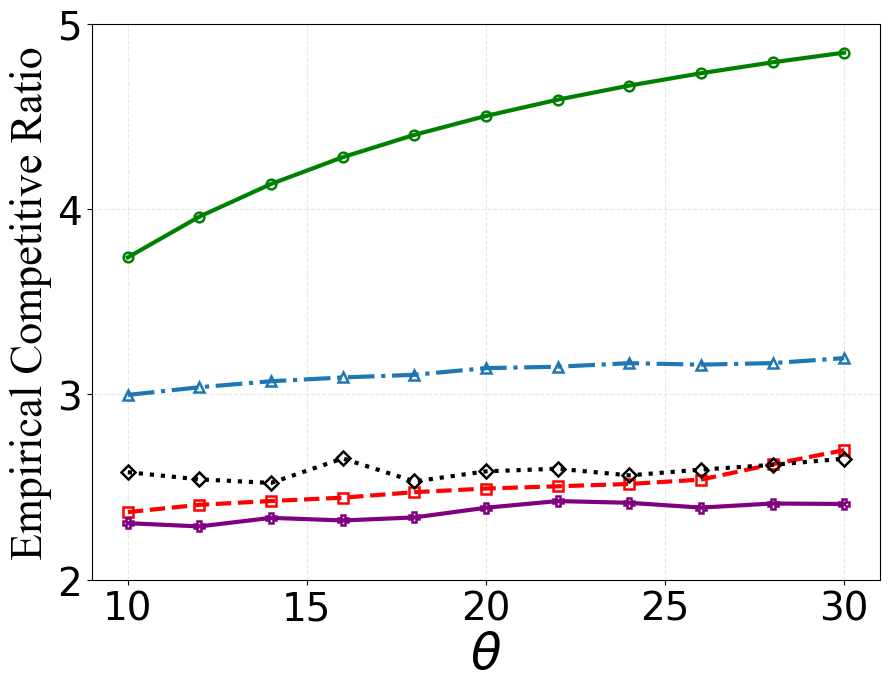

In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt
def plot_combined_cr_vs_u_over_l(combined_df, save_path=None):
    df = combined_df.copy()

    alg_order = ["FCFS", "OPS", "OPS*", "D-OPS", "D-OPS*"]
    style_map = {
        "FCFS": {"marker": "o", "linestyle": "-", "linewidth": 3, "color": "green"},
        "OPS": {"marker": "^", "linestyle": "-.", "linewidth": 3, "color": "#1f77b4"},
        "OPS*": {"marker": "s", "linestyle": "--", "linewidth": 3, "color": "red"},
        "D-OPS": {"marker": "D", "linestyle": ":", "linewidth": 3, "color": "black"},
        "D-OPS*": {"marker": "P", "linestyle": "-", "linewidth": 3, "color": "purple"},
    }
    plt.figure(figsize=(9, 7))
    for alg in alg_order:
        sub = df[df["algorithm"] == alg].sort_values("U_over_L")
        sub = sub[sub["U_over_L"] >= 10]

        if sub.empty:
            continue
        plt.plot(
            sub["U_over_L"],
            sub["avg_cr_over_loads"],
            label=alg,
            marker=style_map[alg]["marker"],
            linestyle=style_map[alg]["linestyle"],
            linewidth=style_map[alg]["linewidth"],
            markersize=7,
            markerfacecolor="none",
            markeredgewidth=1.8,
            color=style_map[alg]["color"],
        )
    xvals = sorted(df["U_over_L"].unique())
    plt.xlabel(r"$\theta$", fontsize=36, fontname="Times New Roman")
    plt.ylabel("Empirical Competitive Ratio", fontsize=32, fontname="Times New Roman")
    plt.grid(True, alpha=0.3, linestyle="--")
    # plt.xticks(xvals, fontsize=20)
    plt.xticks([10, 15, 20, 25, 30], fontsize=28)
    plt.yticks([2.0, 3.0, 4.0, 5.0], fontsize=28)
    # plt.legend(fontsize=17, frameon=True, loc="best")
    plt.tight_layout()
    if save_path is not None:
        out_dir = os.path.dirname(save_path)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved plot to:", save_path)
    plt.show()

combined_path = "ul_sweep_ml_only_stationwise/combined_avg_cr_vs_u_over_l_stationwise.csv"
    
combined_df = pd.read_csv(combined_path)
VALUE_MODE = "stationwise"
ML_ROOT = f"ul_sweep_ml_only_{VALUE_MODE}"
plot_combined_cr_vs_u_over_l(
    combined_df,
    save_path=os.path.join(ML_ROOT, f"combined_avg_cr_vs_u_over_l_{VALUE_MODE}_v2.pdf"),
)

# Compute percentage improvement of D-OPS over FCFS


Percentage improvement of D-OPS over FCFS for each U/L:

    U_over_L  fcfs_avg_cr  dops_avg_cr  pct_improvement
0        6.0     3.081029     2.302035        33.839354
1        8.0     3.457635     2.502478        38.168476
2       10.0     3.740226     2.580319        44.952099
3       12.0     3.960297     2.541624        55.817573
4       14.0     4.136589     2.522601        63.981065
5       16.0     4.281050     2.654709        61.262473
6       18.0     4.401615     2.530674        73.930521
7       20.0     4.503772     2.585126        74.218700
8       22.0     4.591451     2.599204        76.648393
9       24.0     4.667535     2.563409        82.083122
10      26.0     4.734186     2.594457        82.473068
11      28.0     4.793058     2.619976        82.942849
12      30.0     4.845440     2.653585        82.599806

--------------------------------------------------
Maximum percentage improvement of D-OPS over FCFS: 82.94% at U/L = 28.0
----------------------------------

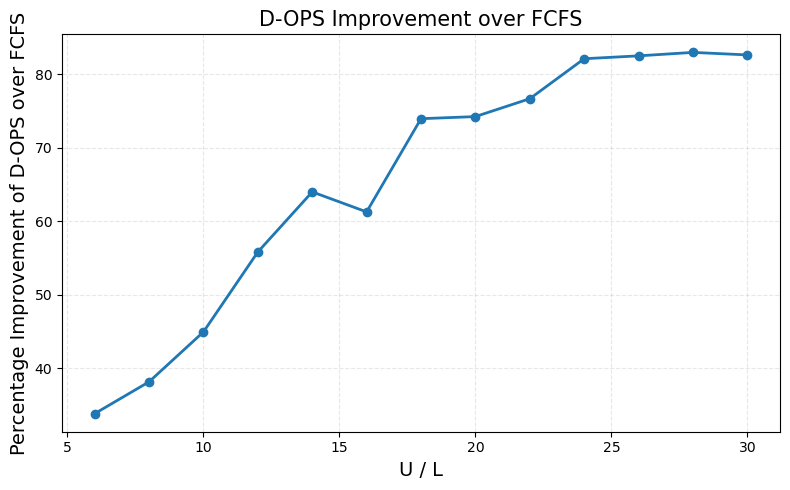

In [40]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Extract FCFS and D-OPS rows
# -----------------------------
fcfs_df = combined_df[combined_df["algorithm"] == "FCFS"][
    ["U_over_L", "avg_cr_over_loads"]
].copy()
fcfs_df = fcfs_df.rename(columns={"avg_cr_over_loads": "fcfs_avg_cr"})

dops_df = combined_df[combined_df["algorithm"] == "D-OPS"][
    ["U_over_L", "avg_cr_over_loads"]
].copy()
dops_df = dops_df.rename(columns={"avg_cr_over_loads": "dops_avg_cr"})

# -----------------------------
# 2. Merge on U/L
# -----------------------------
improvement_df = fcfs_df.merge(dops_df, on="U_over_L", how="inner")

# -----------------------------
# 3. Compute percentage improvement
# Formula: (FCFS - D-OPS) / D-OPS * 100
# -----------------------------
improvement_df["pct_improvement"] = (
    (improvement_df["fcfs_avg_cr"] - improvement_df["dops_avg_cr"])
    / improvement_df["dops_avg_cr"]
) * 100

# Sort by U/L for readability
improvement_df = improvement_df.sort_values("U_over_L").reset_index(drop=True)

# -----------------------------
# 4. Print full table
# -----------------------------
print("\nPercentage improvement of D-OPS over FCFS for each U/L:\n")
print(improvement_df)

# -----------------------------
# 5. Report maximum improvement
# -----------------------------
max_row = improvement_df.loc[improvement_df["pct_improvement"].idxmax()]

print("\n--------------------------------------------------")
print(
    f"Maximum percentage improvement of D-OPS over FCFS: "
    f"{max_row['pct_improvement']:.2f}% at U/L = {max_row['U_over_L']}"
)
print("--------------------------------------------------\n")

# -----------------------------
# 6. Save to CSV
# -----------------------------
improvement_csv = os.path.join(ML_ROOT, f"dops_vs_fcfs_improvement_{VALUE_MODE}.csv")
improvement_df.to_csv(improvement_csv, index=False)
print("Saved improvement table to:", improvement_csv)

# -----------------------------
# 7. Optional plot
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    improvement_df["U_over_L"],
    improvement_df["pct_improvement"],
    marker="o",
    linewidth=2,
)
plt.xlabel("U / L", fontsize=14)
plt.ylabel("Percentage Improvement of D-OPS over FCFS", fontsize=14)
plt.title("D-OPS Improvement over FCFS", fontsize=15)
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()

improvement_plot_path = os.path.join(
    ML_ROOT, f"dops_vs_fcfs_improvement_{VALUE_MODE}.pdf"
)
plt.savefig(improvement_plot_path, dpi=300, bbox_inches="tight")
print("Saved improvement plot to:", improvement_plot_path)

plt.show()

# Compute percentage improvement of OPS over FCFS


Percentage improvement of OPS over FCFS for each U/L:

    U_over_L  fcfs_avg_cr  ops_avg_cr  pct_improvement
0        6.0     3.081029    2.797532        10.133803
1        8.0     3.457635    2.928294        18.076791
2       10.0     3.740226    2.997573        24.775130
3       12.0     3.960297    3.039050        30.313672
4       14.0     4.136589    3.071507        34.676170
5       16.0     4.281050    3.092004        38.455496
6       18.0     4.401615    3.106185        41.704859
7       20.0     4.503772    3.142270        43.328612
8       22.0     4.591451    3.149827        45.768377
9       24.0     4.667535    3.169056        47.284712
10      26.0     4.734186    3.160961        49.770433
11      28.0     4.793058    3.169331        51.232465
12      30.0     4.845440    3.196415        51.589858

--------------------------------------------------
Maximum percentage improvement of OPS over FCFS: 51.59% at U/L = 30.0
--------------------------------------------------



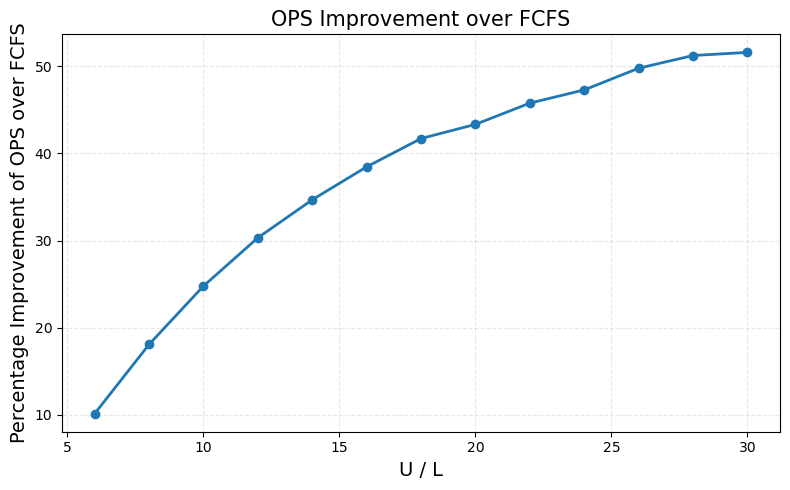

In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Extract FCFS and OPS rows
# -----------------------------
fcfs_df = combined_df[combined_df["algorithm"] == "FCFS"][
    ["U_over_L", "avg_cr_over_loads"]
].copy()
fcfs_df = fcfs_df.rename(columns={"avg_cr_over_loads": "fcfs_avg_cr"})

ops_df = combined_df[combined_df["algorithm"] == "OPS"][
    ["U_over_L", "avg_cr_over_loads"]
].copy()
ops_df = ops_df.rename(columns={"avg_cr_over_loads": "ops_avg_cr"})

# -----------------------------
# 2. Merge on U/L
# -----------------------------
improvement_df = fcfs_df.merge(ops_df, on="U_over_L", how="inner")

# -----------------------------
# 3. Compute percentage improvement
# Formula: (FCFS - OPS) / OPS * 100
# -----------------------------
improvement_df["pct_improvement"] = (
    (improvement_df["fcfs_avg_cr"] - improvement_df["ops_avg_cr"])
    / improvement_df["ops_avg_cr"]
) * 100

# Sort by U/L
improvement_df = improvement_df.sort_values("U_over_L").reset_index(drop=True)

# -----------------------------
# 4. Print full table
# -----------------------------
print("\nPercentage improvement of OPS over FCFS for each U/L:\n")
print(improvement_df)

# -----------------------------
# 5. Report maximum improvement
# -----------------------------
max_row = improvement_df.loc[improvement_df["pct_improvement"].idxmax()]

print("\n--------------------------------------------------")
print(
    f"Maximum percentage improvement of OPS over FCFS: "
    f"{max_row['pct_improvement']:.2f}% at U/L = {max_row['U_over_L']}"
)
print("--------------------------------------------------\n")

# -----------------------------
# 6. Save to CSV
# -----------------------------
improvement_csv = os.path.join(ML_ROOT, f"ops_vs_fcfs_improvement_{VALUE_MODE}.csv")
improvement_df.to_csv(improvement_csv, index=False)
print("Saved improvement table to:", improvement_csv)

# -----------------------------
# 7. Optional plot
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    improvement_df["U_over_L"],
    improvement_df["pct_improvement"],
    marker="o",
    linewidth=2,
)
plt.xlabel("U / L", fontsize=14)
plt.ylabel("Percentage Improvement of OPS over FCFS", fontsize=14)
plt.title("OPS Improvement over FCFS", fontsize=15)
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()

improvement_plot_path = os.path.join(
    ML_ROOT, f"ops_vs_fcfs_improvement_{VALUE_MODE}.pdf"
)
plt.savefig(improvement_plot_path, dpi=300, bbox_inches="tight")
print("Saved improvement plot to:", improvement_plot_path)

plt.show()